# Visualizing the Author-Interaction Networks

Renders any of the **directed, weighted author-interaction networks** produced
by this project's network notebooks. In every one of them a node is an
**author** and a directed edge `referenced_author -> author` is weighted by how
many times the second author interacted with (retweeted / replied to / quoted)
the first, so the *same* pipeline renders any of them.

**Where the networks come from** (all written to `networks_folder` as GML):

| Source notebook | Networks |
|---|---|
| [`02_Processing/02_sanity_check_and_network_generation.ipynb`](../02_Processing/02_sanity_check_and_network_generation.ipynb) | `Test_Network.gml`, `Full_Network.gml` |
| [`04_Network_Analysis/01_network_analysis.ipynb`](01_network_analysis.ipynb) | `LWCC.gml`, `90TS_LWCC.gml`, `Final_OutThreshold1.gml`, and the community-annotated `Final_OutThreshold1_{leiden_fast,louvain,label_propagation}.gml` |

Pick which one to draw with the `NETWORK` switch in the Setup cell. The three
`Final_OutThreshold1_*` graphs carry a precomputed `community_<method>` vertex
attribute; when `USE_PRECOMPUTED_COMMUNITY` is on, the notebook colors by *those*
labels instead of recomputing communities.

**The pipeline in one sentence:** load the `.gml` with **igraph** (C core -> fast
parsing, Leiden communities, large-graph layouts), then render it three
complementary ways -- **Datashader** for pixel-perfect static rasters of *every*
node and edge (optionally with hammer edge bundling), **Matplotlib** for a
publication-grade composite, and **ipysigma** (sigma.js / WebGL) for interactive
exploration and a standalone HTML file.

> **How to use:** set `NETWORK` in the Setup cell below, then *Runtime -> Run
> all*. If the selected `.gml` is missing, a synthetic social-media-like network
> is generated so every cell still runs end-to-end.

## Why this particular stack?

| Stage | Tool | Why it scales |
|---|---|---|
| Parse `.gml`, graph ops | python-igraph | C core; holds multi-million-edge graphs where `networkx.read_gml` crawls |
| Communities | igraph's built-in **Leiden** | Successor to Louvain (Traag et al. 2019); seconds on millions of edges |
| Layout | igraph `layout_fr(grid=...)` / `layout_drl` | Grid-accelerated FR and DrL are designed for large graphs |
| Static rendering | Datashader | Rasterizes arbitrarily many points/lines -- no browser/vector limits |
| Edge bundling | `datashader.bundling.hammer_bundle` | Density-based edge bundling |
| Interactive | ipysigma | WebGL renderer (sigma.js); comfortable to ~10^4-10^5 nodes, exports self-contained HTML |


In [1]:
import os
from pathlib import Path
import sys

# --- ENVIRONMENT SWITCH ---
# Set to True if running on local machine with Google Drive Desktop mounted
# Set to False if running in Google Colab cloud
RUNNING_LOCALLY = False

if RUNNING_LOCALLY:
    # --- REPO ROOT ON sys.path (harmless here; this notebook uses no src imports) ---
    _REPO_ROOT = str(Path(os.getcwd()).resolve().parents[1])
    if _REPO_ROOT not in sys.path:
        sys.path.insert(0, _REPO_ROOT)
    # Standard macOS path for Google Drive Desktop
    BASE_PATH = Path('/Volumes/GoogleDrive/My Drive/Colab Projects/AI Public Trust')
else:
    # Google Colab cloud path
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/My Drive/Colab Projects/AI Public Trust')

# Shared folders (same variables as the other notebooks)
datasets_folder = BASE_PATH / 'Data Sets'
networks_folder = BASE_PATH / 'Data Sets/Networks/'

# --- WHICH NETWORK TO VISUALIZE --------------------------------------------
# Registry of every network written by the generation / analysis notebooks.
# All are directed, weighted author-interaction graphs in GML, so the same
# pipeline renders any of them. Each entry: key -> (filename, source_nb, note).
NETWORKS = {
    'Test':                    ('Test_Network.gml',                          '02', 'small test interaction network'),
    'Full':                    ('Full_Network.gml',                          '02', 'full author-interaction network (large)'),
    'LWCC':                    ('LWCC.gml',                                   '01', 'largest weakly-connected component of Full'),
    '90TS_LWCC':               ('90TS_LWCC.gml',                             '01', 'total-strength pruned (keep 90% of weight), then LWCC'),
    'Final_OutThreshold1':     ('Final_OutThreshold1.gml',                   '01', 'out-strength >= 1.0 pruned network'),
    'Final_leiden_fast':       ('Final_OutThreshold1_leiden_fast.gml',       '01', 'out-thresh network + Leiden-fast community labels'),
    'Final_louvain':           ('Final_OutThreshold1_louvain.gml',           '01', 'out-thresh network + Louvain community labels'),
    'Final_label_propagation': ('Final_OutThreshold1_label_propagation.gml', '01', 'out-thresh network + label-propagation community labels'),
}

# <-- pick any key from NETWORKS above
NETWORK = 'Final_leiden_fast'

_fname, _src, _note = NETWORKS[NETWORK]
GML_PATH = networks_folder / _fname
# Visualization artifacts land next to the networks on Drive, one folder per network.
OUTPUT_DIR = networks_folder / f'viz_outputs_{NETWORK}'

print(f'NETWORK={NETWORK!r}  (from notebook {_src}: {_note})')
print(f'  GML_PATH   = {GML_PATH}')
print(f'  OUTPUT_DIR = {OUTPUT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
NETWORK='Final_leiden_fast'  (from notebook 01: out-thresh network + Leiden-fast community labels)
  GML_PATH   = /content/drive/My Drive/Colab Projects/AI Public Trust/Data Sets/Networks/Final_OutThreshold1_leiden_fast.gml
  OUTPUT_DIR = /content/drive/My Drive/Colab Projects/AI Public Trust/Data Sets/Networks/viz_outputs_Final_leiden_fast


## 0. Setup

### 0.1 Install dependencies

Colab already ships `networkx`, `matplotlib`, `pandas`, `numpy` and `scipy`.
We add the graph engine (`python-igraph`), the renderers (`datashader`,
`ipysigma`) and the two extras `hammer_bundle` needs at runtime (`dask`,
`scikit-image`). Guarded by `if not RUNNING_LOCALLY` so it is a no-op locally.


In [2]:
import os
if not RUNNING_LOCALLY:
    print('Running Colab setup shell commands...')
    !pip install -q python-igraph datashader colorcet ipysigma "dask[dataframe]" scikit-image pyarrow tqdm psutil
else:
    print('Running locally: Skipping Colab shell setup.')


Running Colab setup shell commands...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 77.2 MB/s eta 0:00:00


### 0.2 Imports

All third-party imports the notebook uses, listed explicitly (per
`notebook_setup.md`). `ipysigma`'s inline widget needs Colab's custom widget
manager; the `try/except` keeps the notebook runnable in plain Jupyter/VS Code.


In [3]:
from pathlib import Path
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil                              # memory guardrails
from tqdm.auto import tqdm                 # progress bars
import networkx as nx                      # used as interchange format only
import igraph as ig                        # the workhorse: I/O, communities, layout

import datashader as ds                    # large-scale rasterization
import datashader.transfer_functions as tf
from datashader.bundling import connect_edges, hammer_bundle
import colorcet as cc                      # perceptually-designed palettes (glasbey)

# ipysigma needs Colab's custom widget manager to display inline widgets.
try:
    from google.colab import output
    output.enable_custom_widget_manager()
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"igraph {ig.__version__} | datashader {ds.__version__} | "
      f"networkx {nx.__version__} | colab: {IN_COLAB}")


igraph 1.0.0 | datashader 0.19.1 | networkx 3.6.1 | colab: True


### 0.3 Configuration

Every knob you might want to touch lives in this one cell. (`GML_PATH` and
`OUTPUT_DIR` were set by the environment cell from the `NETWORK` switch.)


In [4]:
# ----------------------------- CONFIGURATION ------------------------------ #
RANDOM_SEED = 42                           # reproducible layouts & sampling

# --- Communities ---
# The Final_OutThreshold1_* networks from 01_network_analysis.ipynb carry a
# precomputed 'community_<method>' vertex attribute. When True, color by those
# labels if present; otherwise (or for networks without them) run Leiden below.
USE_PRECOMPUTED_COMMUNITY = True

# --- Layout ---
LAYOUT_METHOD = "fr"                       # "fr" (fast, default) | "drl" | "lgl"
FR_ITERATIONS = 500                        # more iterations = better untangling

# Reframe: after layout, clip node coords to this central percentile per axis
# before scaling to [0,1]. 100.0 = no clip (raw). Lower it (99, 98) so a few
# far-flung outliers can't define the frame and squash the core into a blob.
CLIP_PCT = 99.0

# --- Static rendering (Datashader) ---
CANVAS_PX = 1600                           # width of the raster in pixels
TOP_COMMUNITIES = 16                       # communities that get their own color
MAX_EDGES_TO_BUNDLE = 150_000              # hammer bundling is the slow step;
                                           # edges are subsampled above this
BUNDLE_PARAMS = dict(                      # see the Datashader networks guide for
    initial_bandwidth=0.10,                # how bandwidth/decay change the look:
    decay=0.70,                            # https://datashader.org/user_guide/Networks.html
    iterations=4,
)

# --- Interactive rendering (ipysigma) ---
MAX_NODES_INTERACTIVE = 30_000             # WebGL stays fluid in this range
MAX_EDGES_INTERACTIVE = 200_000

# --- Guardrails: per-stage time budgets (seconds). A stage that exceeds its
#     budget is KILLED, so a hung run fails loudly instead of hanging silently.
TIME_BUDGETS = {
    "layout":   900,     # 15 min
    "bundling": 900,     # 15 min
    "render":   300,
}
ABORT_IF_ESTIMATE_EXCEEDS_BUDGET = True    # pre-flight probes; False = just warn

# --------------------------------------------------------------------------- #
random.seed(RANDOM_SEED)                   # python-igraph draws from Python's RNG
np.random.seed(RANDOM_SEED)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
warnings.filterwarnings("ignore", category=FutureWarning)
print("config loaded | budgets:", TIME_BUDGETS, "| output dir:", OUTPUT_DIR)


config loaded | budgets: {'layout': 900, 'bundling': 900, 'render': 300} | output dir: /content/drive/My Drive/Colab Projects/AI Public Trust/Data Sets/Networks/viz_outputs_Final_leiden_fast


### 0.4 Progress bars & guardrails

Long cells that print nothing are indistinguishable from hung cells. This
toolkit fixes that for every expensive stage:

* **`Stage`** — announces each step, times it, logs peak memory (§8 prints a
  summary table).
* **`run_guarded`** — the important one. igraph's layouts are C calls that
  **hold the GIL**: a progress thread can't tick during them, and `Ctrl-C`
  won't interrupt them. So we run them in a **forked subprocess**, show a live
  elapsed ticker in the notebook, and **terminate them** if they blow the time
  budget. Nothing can hang forever.
* **`require`** — hard assertions with actionable messages, so a bad layout
  fails *here* rather than silently producing an empty PNG three cells later.

> *Why no per-iteration bar for the layout?* Feeding igraph's FR intermediate
> coordinates (`seed=…`) to chunk it disables its grid optimization — measured
> **~160× slower** and lower quality. An elapsed ticker + ETA + kill switch is
> strictly better than a "pretty" bar that costs you an hour.

In [5]:
import multiprocessing as mp
from contextlib import contextmanager

STAGE_LOG = []                                   # filled by Stage, printed in §8


def require(condition: bool, message: str) -> None:
    """Hard guardrail: abort the run with an actionable message."""
    if not condition:
        raise RuntimeError(f"GUARDRAIL FAILED - {message}")


def check_memory(need_gb: float, what: str) -> None:
    """Refuse to start a stage that obviously won't fit in RAM."""
    avail = psutil.virtual_memory().available / 1e9
    require(need_gb < avail,
            f"{what} needs ~{need_gb:.1f} GB but only {avail:.1f} GB is free. "
            f"Reduce the graph (k-core / top-degree) or the parameters.")
    if need_gb > 0.6 * avail:
        print(f"  warning: {what} may use ~{need_gb:.1f} GB of {avail:.1f} GB free")


@contextmanager
def Stage(name: str):
    """Time a stage, report it, and record it for the final summary table."""
    print(f"> {name} ...", flush=True)
    t0 = time.time()
    ok = True
    try:
        yield
    except BaseException:
        ok = False
        raise                                    # never swallow the error
    finally:
        dt = time.time() - t0
        rss = psutil.Process().memory_info().rss / 1e9
        STAGE_LOG.append({"stage": name, "seconds": round(dt, 1),
                          "status": "ok" if ok else "FAILED", "RSS_GB": round(rss, 2)})
        print(f"{'v' if ok else 'x'} {name}: {dt:.1f}s (RSS {rss:.1f} GB)", flush=True)


def _worker(conn, fn, args, kwargs):
    """Child-process entry point: run fn, ship back the result or the error."""
    try:
        conn.send(("ok", fn(*args, **kwargs)))
    except BaseException as e:                   # noqa: BLE001
        conn.send(("err", repr(e)))
    finally:
        conn.close()


def run_guarded(fn, *args, desc: str, timeout_s: float, eta_s: float = None,
                tick: float = 1.0, **kwargs):
    """Run fn in a forked subprocess with a live ticker and a hard kill switch.

    Used for stages that would otherwise be black boxes:
      - igraph layouts: C code that holds the GIL (uninterruptible in-process)
      - hammer_bundle: long, and worth being able to abort

    Guarantees: you always see elapsed time; the stage cannot run past
    `timeout_s`; a child killed by the OS (OOM) is reported as such.
    """
    ctx = mp.get_context("fork")                 # fork => no pickling of inputs
    parent, child = ctx.Pipe(duplex=False)
    proc = ctx.Process(target=_worker, args=(child, fn, args, kwargs), daemon=True)
    t0 = time.time()
    proc.start()
    child.close()                                # only the child holds the writer

    eta = f" / est {eta_s:.0f}s" if eta_s else ""
    fmt = "{desc} | elapsed {elapsed}" + eta + f" | budget {timeout_s:.0f}s"
    try:
        with tqdm(desc=desc, bar_format=fmt) as bar:
            while not parent.poll(tick):         # poll = the heartbeat
                bar.refresh()                    # keeps the ticker alive
                if not proc.is_alive():          # died without sending anything
                    require(False, f"'{desc}' subprocess died (exit "
                                   f"{proc.exitcode}) - almost always out-of-memory")
                if time.time() - t0 > timeout_s:
                    proc.terminate()
                    require(False, f"'{desc}' exceeded its {timeout_s:.0f}s budget "
                                   f"and was killed. Raise TIME_BUDGETS, shrink the "
                                   f"graph, or switch to a cheaper method.")
        status, payload = parent.recv()
    finally:
        if proc.is_alive():
            proc.terminate()
        proc.join()

    require(status == "ok", f"'{desc}' failed inside the subprocess: {payload}")
    return payload


def validate_positions(xy: np.ndarray, n_expected: int) -> None:
    """Catch the three ways a layout silently goes wrong."""
    require(xy.shape == (n_expected, 2),
            f"layout returned {xy.shape}, expected ({n_expected}, 2)")
    require(np.isfinite(xy).all(),
            "layout contains NaN/inf - usually caused by non-positive edge weights")
    require(float((xy.max(0) - xy.min(0)).max()) > 0,
            "layout is degenerate (every node at the same point)")


print("guardrails armed | budgets:", TIME_BUDGETS)

guardrails armed | budgets: {'layout': 900, 'bundling': 900, 'render': 300}


## 1. Load the network

### 1.1 A robust GML loader

GML is a loosely specified format, and files written by Gephi, NetworkX,
igraph or hand-rolled exporters differ in small ways. The strategy below is:
**try igraph's C parser first** (orders of magnitude faster and far more
memory-efficient on big files), and only fall back to `networkx.read_gml`
(slower, but very tolerant) if it fails — converting the result back to
igraph so the rest of the pipeline is identical either way.

In [6]:
def load_gml(path: Path) -> ig.Graph:
    """Read a .gml file into an igraph Graph, trying the fast parser first.

    Returns an igraph.Graph. Vertex attribute ``node_label`` is guaranteed to
    exist (best-effort human-readable name), and ``weight`` on edges is
    coerced to float when present.
    """
    path = Path(path)
    t0 = time.time()
    try:
        g = ig.Graph.Read_GML(str(path))                 # C parser: fast path
        parser = "igraph"
    except Exception as err:                             # noqa: BLE001 - GML is messy
        print(f"igraph parser failed ({err!r}); falling back to networkx …")
        gx = nx.read_gml(path, label="id")               # label='id' avoids
        g = ig.Graph.from_networkx(gx)                   # duplicate-label errors
        parser = "networkx"
    print(f"Parsed with {parser} in {time.time() - t0:.1f}s")

    # ---- Normalize a display name onto every vertex -------------------- #
    # GML files may carry 'label', 'name', 'id', or nothing at all.
    vattrs = g.vs.attributes()
    for candidate in ("label", "name", "_nx_name", "id"):
        if candidate in vattrs:
            g.vs["node_label"] = [str(v) for v in g.vs[candidate]]
            break
    else:
        g.vs["node_label"] = [str(i) for i in range(g.vcount())]

    # ---- Make sure edge weights (if any) are usable floats ------------- #
    if "weight" in g.es.attributes():
        w = np.asarray(g.es["weight"], dtype=float)
        w[~np.isfinite(w)] = 1.0
        # force-directed layouts require strictly positive weights
        w[w <= 0] = w[w > 0].min() if (w > 0).any() else 1.0
        g.es["weight"] = w.tolist()
    return g

### 1.2 Demo fallback: a synthetic social-media-like network

If `GML_PATH` doesn't exist we build a stochastic block model (~30 k nodes,
~40 unequal communities, weighted edges) and write it to disk, so the rest of
the notebook demonstrates itself. **Delete nothing — this cell is a no-op
when your real file is present.**

In [7]:
def make_demo_network(path: Path, n_blocks: int = 40, seed: int = RANDOM_SEED) -> None:
    """Write a synthetic weighted 'social network' to *path* as GML.

    Structure = SBM (communities) + a power-law overlay (hubs/influencers),
    which reproduces the two signatures of real platforms: modular structure
    AND a heavy-tailed degree distribution.
    """
    rng = np.random.default_rng(seed)

    # Unequal community sizes (lognormal) look far more like real platforms
    # than equal blocks do.
    sizes = np.maximum(80, rng.lognormal(mean=6.3, sigma=0.55, size=n_blocks).astype(int))
    n = int(sizes.sum())

    # Denser inside communities than between them. p_in is scaled per block so
    # every community has a similar expected internal degree.
    p_out = 2.0 / n
    p_in = np.minimum(0.9, 12.0 / sizes)              # ~12 internal neighbors each
    pref = np.full((n_blocks, n_blocks), p_out)
    np.fill_diagonal(pref, p_in)

    try:    # igraph >= 1.0 signature
        sbm = ig.Graph.SBM(pref.tolist(), sizes.tolist())
    except TypeError:  # igraph 0.x signature had a leading n argument
        sbm = ig.Graph.SBM(n, pref.tolist(), sizes.tolist())

    # Hub overlay: a static power-law graph on the same vertices adds
    # celebrity-style high-degree nodes (exponent 2.0 -> very heavy tail).
    hubs = ig.Graph.Static_Power_Law(n, 2 * n, exponent_out=2.0)
    g = ig.Graph(n=n, edges=sbm.get_edgelist() + hubs.get_edgelist()).simplify()

    g.vs["label"] = [f"user_{i:05d}" for i in range(n)]
    # Heavy-tailed interaction weights, like retweet/reply counts.
    g.es["weight"] = np.round(rng.pareto(2.5, g.ecount()) + 1, 2).tolist()
    g.write_gml(str(path))
    print(f"Demo network written to {path}: {g.vcount():,} nodes / {g.ecount():,} edges")


if not GML_PATH.exists():
    # IMPORTANT: never write the synthetic graph into networks_folder under a
    # real network's filename - a later analysis run could mistake it for real
    # data. The demo lives in OUTPUT_DIR and GML_PATH is repointed in-session.
    demo_path = OUTPUT_DIR / "demo_network.gml"
    print(f"'{GML_PATH}' not found - generating a demo network at '{demo_path}' instead.")
    if not demo_path.exists():
        make_demo_network(demo_path)
    GML_PATH = demo_path

with Stage("load GML"):
    G_raw = load_gml(GML_PATH)

# Guardrails: fail now, not five cells later.
require(G_raw.vcount() > 0, f"{GML_PATH} parsed to an empty graph")
require(G_raw.ecount() > 0, f"{GML_PATH} has nodes but no edges - nothing to lay out")
check_memory(G_raw.ecount() * 250 / 1e9, "layout + rendering tables")

> load GML ...
Parsed with igraph in 62.3s
v load GML: 63.5s (RSS 4.7 GB)


### 1.3 First look

Before drawing anything, know what you're holding: order, size, density,
degree statistics and how fragmented the graph is. These numbers also drive
choices later (layout method, whether the interactive view needs reducing).

In [8]:
def describe(g: ig.Graph, name: str = "graph") -> None:
    """Print a compact structural summary of an igraph Graph."""
    deg = np.asarray(g.degree())
    comps = g.connected_components(mode="weak")
    pairs = max(1, g.vcount() * (g.vcount() - 1))       # ordered vertex pairs
    density = g.ecount() / pairs * (1 if g.is_directed() else 2)
    print(
        f"--- {name} ---\n"
        f"nodes: {g.vcount():>12,}\n"
        f"edges: {g.ecount():>12,}\n"
        f"directed: {g.is_directed()},  weighted: {'weight' in g.es.attributes()}\n"
        f"density: {density:.2e}\n"
        f"degree  mean/median/max: {deg.mean():.1f} / {np.median(deg):.0f} / {deg.max():,}\n"
        f"components: {len(comps):,} (largest: {max(comps.sizes()):,} nodes)"
    )

describe(G_raw, "raw network")

--- raw network ---
nodes:    1,984,599
edges:    4,453,989
directed: False,  weighted: True
density: 2.26e-06
degree  mean/median/max: 4.5 / 1 / 72,690
components: 1 (largest: 1,984,599 nodes)


## 2. Preprocess for visualization

Three standard steps before spatializing a big social graph. None of them
change your *data on disk* — they produce the view we draw.

### 2.1 Undirect, deduplicate, drop self-loops

Force-directed layouts and most community detection operate on the undirected
backbone. Parallel edges are collapsed (summing weights, so a pair that
interacted 10× still pulls 10× harder) and self-loops — meaningless for
spatialization — are dropped.

In [9]:
def to_viz_backbone(g: ig.Graph) -> ig.Graph:
    """Undirected, simple (no loops / multi-edges) copy for layout & rendering."""
    h = g.copy()
    has_w = "weight" in h.es.attributes()
    if h.is_directed():
        # collapse: a<->b reciprocal pairs become one edge; weights are summed
        h = h.as_undirected(mode="collapse",
                            combine_edges={"weight": "sum"} if has_w else None)
    h = h.simplify(multiple=True, loops=True,
                   combine_edges={"weight": "sum"} if has_w else None)
    return h

G = to_viz_backbone(G_raw)
describe(G, "undirected simple backbone")

--- undirected simple backbone ---
nodes:    1,984,599
edges:    4,453,989
directed: False,  weighted: True
density: 2.26e-06
degree  mean/median/max: 4.5 / 1 / 72,690
components: 1 (largest: 1,984,599 nodes)


### 2.2 Keep the giant component

Force-directed layouts scatter disconnected fragments arbitrarily around the
frame, burying the structure you care about. The near-universal convention is
to lay out and draw the **giant (largest) connected component** and report
what was dropped. If your analysis needs the fragments, visualize them
separately.

In [10]:
components = G.connected_components(mode="weak")
G_giant = components.giant()

dropped_nodes = G.vcount() - G_giant.vcount()
print(f"Keeping giant component: {G_giant.vcount():,} nodes / {G_giant.ecount():,} edges "
      f"({dropped_nodes:,} nodes in {len(components) - 1:,} smaller components dropped)")

Keeping giant component: 1,984,599 nodes / 4,453,989 edges (0 nodes in 0 smaller components dropped)


### 2.3 Optional reducers (kept as tools, not applied)

For *extremely* large or noisy graphs two standard reductions help before the
interactive view — we define them here and use the degree-based one later in
§5.4:

* **k-core**: iteratively strip nodes of degree < k; removes the periphery
  fuzz while preserving the dense heart of the network.
* **top-degree induced subgraph**: keep the N highest-degree accounts and the
  edges among them — the "who matters" view.

In [11]:
def k_core(g: ig.Graph, k: int) -> ig.Graph:
    """Return the k-core of g (max subgraph where every node has degree >= k)."""
    coreness = np.asarray(g.coreness())          # shell index per vertex, O(E)
    return g.induced_subgraph(np.flatnonzero(coreness >= k).tolist())

def top_degree_subgraph(g: ig.Graph, n_keep: int) -> ig.Graph:
    """Induced subgraph on the n_keep highest-degree vertices (then its giant CC)."""
    if g.vcount() <= n_keep:
        return g
    order = np.argsort(g.degree())[::-1][:n_keep]
    sub = g.induced_subgraph(order.tolist())
    return sub.connected_components(mode="weak").giant()

print(f"2-core of the giant component: {k_core(G_giant, 2).vcount():,} nodes "
      f"(vs {G_giant.vcount():,})")

2-core of the giant component: 718,281 nodes (vs 1,984,599)


## 3. Compute the structure we will encode visually

A hairball with uniform dots says nothing. The two attributes that carry the
most information in social-network figures are **degree** (→ node size) and
**community** (→ node color).

### 3.1 Degree

In [12]:
degree = np.asarray(G_giant.degree())
weights = "weight" if "weight" in G_giant.es.attributes() else None
print(f"degree: mean {degree.mean():.1f}, p90 {np.percentile(degree, 90):.0f}, "
      f"max {degree.max():,}")

degree: mean 4.5, p90 5, max 72,690


### 3.2 Communities

Node color encodes community. Two sources, in order of preference:

1. **Precomputed labels** — the `Final_OutThreshold1_*` networks from
   `01_network_analysis.ipynb` already store a `community_<method>` vertex
   attribute (Leiden-fast / Louvain / label-propagation). When
   `USE_PRECOMPUTED_COMMUNITY` is on and such an attribute is present, we color
   by it directly, so the figure shows *exactly* the communities that notebook
   found.
2. **Leiden, computed here** — for networks without precomputed labels (Test,
   Full, LWCC, 90TS_LWCC, or the un-annotated Final_OutThreshold1), we run
   Leiden (Traag, Waltman & van Eck 2019): the modern successor to Louvain,
   shipped inside igraph, seconds on millions of edges.

Either way, because big social graphs produce hundreds of tiny communities we
relabel them **by size**: the `TOP_COMMUNITIES` largest keep individual colors,
everything else becomes a single grey `"other"` class — this is what keeps the
final figure legible.


In [13]:
# ---- Community labels: reuse precomputed ones if present, else run Leiden -- #
precomputed = [a for a in G_giant.vs.attributes() if a.lower().startswith("community")]

if USE_PRECOMPUTED_COMMUNITY and precomputed:
    attr = precomputed[0]
    # Map arbitrary stored labels -> contiguous 0..k-1 integers.
    raw = np.asarray(G_giant.vs[attr])
    _uniq, membership = np.unique(raw, return_inverse=True)
    n_comm = int(len(_uniq))
    COMMUNITY_SOURCE = attr.replace("community", "").strip("_") or "precomputed"
    print(f"using precomputed communities from vertex attribute '{attr}': "
          f"{n_comm:,} communities")
else:
    with Stage("Leiden community detection"):
        partition = G_giant.community_leiden(
            objective_function="modularity",   # optimize modularity (CPM is the alternative)
            weights=weights,                   # respect interaction intensity if present
            n_iterations=5,                    # a few refinement passes; cheap and stabler
        )
    membership = np.asarray(partition.membership)
    n_comm = int(membership.max() + 1)
    COMMUNITY_SOURCE = "Leiden"
    print(f"Leiden: {n_comm:,} communities, modularity {partition.modularity:.3f}")

require(n_comm >= 1, "no communities found")

# ---- Relabel communities by size: 0 = largest, 1 = second largest, ... ---- #
sizes = np.bincount(membership)
order = np.argsort(sizes)[::-1]                  # community ids, largest first
rank_of = np.empty_like(order); rank_of[order] = np.arange(n_comm)
comm_rank = rank_of[membership]                  # per-node size rank

# Display label: named color class for the big ones, 'other' for the rest.
comm_display = np.where(comm_rank < TOP_COMMUNITIES,
                        np.char.add("C", comm_rank.astype(str)), "other")

shown = min(TOP_COMMUNITIES, n_comm)
print(f"top {shown} communities cover "
      f"{sizes[order][:shown].sum() / G_giant.vcount():.0%} of nodes")


using precomputed communities from vertex attribute 'communityleidenfast': 1,458 communities
top 16 communities cover 87% of nodes


## 4. Layout at scale

### 4.1 Choosing an algorithm

The layout is the computational bottleneck, so choose deliberately:

| Method | igraph call | Character | Rough cost |
|---|---|---|---|
| **FR (grid)** — default | `layout_fruchterman_reingold(grid="grid")` | Grid-accelerated spring layout; the pragmatic choice | ~O(iter·(V+E)) — minutes at 10⁵–10⁶ nodes |
| **DrL** | `layout_drl()` | Multi-phase, built for large graphs; separates clusters aggressively | slower; tens of minutes when very large |
| **LGL** | `layout_lgl()` | Spanning-tree-guided; good for sparse, tree-ish giants | similar to FR |

Two things `networkx` users should know: `nx.spring_layout` and even the
built-in `nx.forceatlas2_layout` compute **all-pairs repulsion (O(V²) per
iteration)** — fine at 10³ nodes, hopeless at 10⁵. And if you specifically
want Gephi-style ForceAtlas2 aesthetics on CPU, the maintained
[`fa2_modified`](https://pypi.org/project/fa2-modified/) package provides
Barnes-Hut FA2; on a Colab **GPU** runtime, RAPIDS cuGraph's `force_atlas2`
(§4.4) does it fastest of all.

### 4.2 Compute the layout

In [14]:
def _layout_call(g, method, fr_iterations, weights, seed):
    """The raw igraph call (this is what runs inside the guarded subprocess)."""
    random.seed(seed)                      # python-igraph draws from Python's RNG
    if method == "fr":
        lay = g.layout_fruchterman_reingold(
            niter=fr_iterations,
            grid="grid",                   # THE switch that makes FR scale: repulsion
            weights=weights,               # only within nearby grid cells, not all pairs
        )
    elif method == "drl":
        lay = g.layout_drl(weights=weights)
    elif method == "lgl":
        lay = g.layout_lgl()
    else:
        raise ValueError(f"unknown layout method: {method!r}")
    return np.asarray(lay.coords, dtype=float)


def estimate_fr_seconds(g, weights, probe_iter: int = 15) -> float:
    """Pre-flight: time a few iterations, extrapolate linearly to the real run.

    FR cost is ~linear in iterations, so this is a decent (deliberately
    conservative - it tends to over-estimate) upper bound on the wait.
    """
    t0 = time.time()
    g.layout_fruchterman_reingold(niter=probe_iter, grid="grid", weights=weights)
    return (time.time() - t0) * FR_ITERATIONS / probe_iter


# ---- Pre-flight: know the cost BEFORE committing to it -------------------- #
eta = None
if LAYOUT_METHOD == "fr":
    eta = estimate_fr_seconds(G_giant, weights)
    print(f"pre-flight: FR on {G_giant.vcount():,} nodes x {FR_ITERATIONS} iters "
          f"~ {eta:.0f}s (budget {TIME_BUDGETS['layout']}s)")
    if eta > TIME_BUDGETS["layout"]:
        msg = (f"estimated layout time ({eta:.0f}s) exceeds the budget "
               f"({TIME_BUDGETS['layout']}s). Lower FR_ITERATIONS, reduce the graph "
               f"(k_core / top_degree_subgraph), or raise TIME_BUDGETS['layout'].")
        require(not ABORT_IF_ESTIMATE_EXCEEDS_BUDGET, msg)
        print("  warning:", msg)

# ---- Run it, with a live ticker and a hard kill switch -------------------- #
with Stage(f"layout ({LAYOUT_METHOD})"):
    xy = run_guarded(_layout_call, G_giant, LAYOUT_METHOD, FR_ITERATIONS,
                     weights, RANDOM_SEED,
                     desc=f"{LAYOUT_METHOD} layout, {G_giant.vcount():,} nodes",
                     timeout_s=TIME_BUDGETS["layout"], eta_s=eta)

validate_positions(xy, G_giant.vcount())     # NaN / degenerate / wrong-shape guard

pre-flight: FR on 1,984,599 nodes x 500 iters ~ 607s (budget 900s)
> layout (fr) ...


fr layout, 1,984,599 nodes | elapsed 00:00 / est 607s | budget 900s

v layout (fr): 430.6s (RSS 4.9 GB)


### 4.3 Normalize coordinates

Every renderer downstream (Datashader canvases, bundling bandwidths, sigma.js
cameras) behaves predictably when coordinates live in a unit box. We rescale
to `[0, 1]` on the longer axis, **preserving the aspect ratio** so the layout
isn't distorted.

In [15]:
def normalize_xy(xy: np.ndarray, clip_pct: float = 100.0) -> np.ndarray:
    """Shift/scale coordinates into [0,1] on the longer axis, keeping aspect.

    If clip_pct < 100, first clip each axis to its central ``clip_pct``% window
    so a handful of far-flung outliers can't define the frame and squash the
    dense core into a central blob. clip_pct=100 reproduces the raw behaviour.
    """
    xy = np.asarray(xy, dtype=float)
    if clip_pct < 100.0:
        half = (100.0 - clip_pct) / 2.0
        lo = np.percentile(xy, half, axis=0)
        hi = np.percentile(xy, 100.0 - half, axis=0)
        xy = np.clip(xy, lo, hi)
    out = xy - xy.min(axis=0)
    span = out.max(axis=0)
    span[span == 0] = 1.0                  # degenerate axis guard
    return out / span.max()

xy = normalize_xy(xy, clip_pct=CLIP_PCT)

# One tidy node table + one edge table drive *all* renderers below.
nodes = pd.DataFrame({
    "x": xy[:, 0],
    "y": xy[:, 1],
    "label": G_giant.vs["node_label"],
    "degree": degree,
    "community": pd.Categorical(comm_display),   # categorical -> datashader count_cat
    "community_rank": comm_rank,
})
src, tgt = map(np.asarray, zip(*G_giant.get_edgelist()))
edges = pd.DataFrame({
    "source": src,                                # integer positions into `nodes`
    "target": tgt,                                # (exactly what datashader expects)
    "weight": (np.asarray(G_giant.es["weight"], dtype=float)
               if weights else np.ones(len(src))),
})
nodes.head()

In [ ]:
# ---- REFRAME PREVIEW (no relayout) — compare percentile-clip levels -------- #
# Node-only rasters at several CLIP_PCT levels so you can pick how hard to pull
# the outliers in, WITHOUT recomputing the 430s layout. Reads the in-memory
# `nodes` if present, else the saved `node_positions.parquet` (works on a fresh
# kernel). Once you pick a level, set CLIP_PCT in the config cell and re-run the
# normalize cell + the render cells (edges are reused; no relayout).
try:
    _nodes = nodes
except NameError:
    _nodes = pd.read_parquet(OUTPUT_DIR / "node_positions.parquet")

def _reframe_xy(df, clip_pct):
    xy = df[["x", "y"]].to_numpy(dtype=float)
    if clip_pct < 100.0:
        half = (100.0 - clip_pct) / 2.0
        lo = np.percentile(xy, half, axis=0)
        hi = np.percentile(xy, 100.0 - half, axis=0)
        xy = np.clip(xy, lo, hi)
    xy = xy - xy.min(axis=0)
    span = xy.max(axis=0); span[span == 0] = 1.0
    return xy / span.max()

# quick diagnostic: how wide is the frame at each percentile vs the bulk?
_raw = _nodes[["x", "y"]].to_numpy(dtype=float)
for _p in (100, 99.5, 99, 98, 95):
    _lo = np.percentile(_raw, (100 - _p) / 2, axis=0)
    _hi = np.percentile(_raw, 100 - (100 - _p) / 2, axis=0)
    print(f"  central {_p:>5}% span:  x={_hi[0]-_lo[0]:.3f}  y={_hi[1]-_lo[1]:.3f}")

_comm = _nodes["community"].astype("category")
_ck = {c: ("#c8c8c8" if c == "other" else cc.glasbey[int(c[1:]) % len(cc.glasbey)])
       for c in _comm.cat.categories}

_levels = [100.0, 99.5, 99.0, 98.0]
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, pct in zip(axes.ravel(), _levels):
    _xy = _reframe_xy(_nodes, pct)
    d = pd.DataFrame({"x": _xy[:, 0], "y": _xy[:, 1]})
    d["community"] = pd.Categorical(_comm.values, categories=_comm.cat.categories)
    cvs = ds.Canvas(plot_width=700, plot_height=700,
                    x_range=(-0.02, 1.02), y_range=(-0.02, 1.02))
    img = tf.dynspread(
        tf.shade(cvs.points(d, "x", "y", agg=ds.count_cat("community")),
                 color_key=_ck, how="eq_hist"),
        threshold=0.9, max_px=2)
    ax.imshow(tf.set_background(img, "white").to_pil())
    ax.set_title(f"CLIP_PCT = {pct}" + ("   (current default — raw)" if pct == 100 else ""))
    ax.set_axis_off()
fig.suptitle("Reframe preview — pick the CLIP_PCT that best de-blobs the core", fontsize=14)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "00_reframe_preview.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved", OUTPUT_DIR / "00_reframe_preview.png")

### 4.4 Optional: GPU ForceAtlas2 with RAPIDS cuGraph (Colab GPU runtime)

If you switch the runtime to a GPU (*Runtime → Change runtime type → T4*),
NVIDIA's RAPIDS stack gives you two big wins with almost no code changes:
[`nx-cugraph`](https://rapids.ai/nx-cugraph/) transparently accelerates
NetworkX algorithms (Louvain, betweenness, PageRank … 50–500×), and
`cugraph.force_atlas2` computes a Gephi-quality ForceAtlas2 layout on graphs
with tens of millions of edges in minutes. The cell below is **disabled by
default** so the notebook runs on the standard CPU runtime; flip `USE_GPU`
after installing.

In [37]:
# [SKIP-TEST]
USE_GPU = False   # set True on a GPU runtime after running the pip line below

# %pip install -q cugraph-cu12 nx-cugraph-cu12 --extra-index-url=https://pypi.nvidia.com

if USE_GPU:
    import cudf, cugraph

    # cuGraph consumes an edge list in GPU memory (cudf DataFrame).
    gdf = cudf.DataFrame({"src": edges["source"], "dst": edges["target"],
                          "wgt": edges["weight"]})
    Ggpu = cugraph.Graph()
    Ggpu.from_cudf_edgelist(gdf, source="src", destination="dst", weight="wgt")

    t0 = time.time()
    pos_gdf = cugraph.force_atlas2(
        Ggpu, max_iter=500,
        outbound_attraction_distribution=True,   # classic Gephi FA2 settings
        lin_log_mode=False, gravity=1.0, scaling_ratio=2.0,
        barnes_hut_optimize=True,
    )
    print(f"GPU ForceAtlas2: {time.time() - t0:.1f}s")

    # Overwrite the CPU layout with the GPU one and rebuild the node table.
    pos_df = pos_gdf.to_pandas().set_index("vertex").sort_index()
    xy = normalize_xy(pos_df[["x", "y"]].to_numpy())
    nodes["x"], nodes["y"] = xy[:, 0], xy[:, 1]

## 5. Visualizations

Four complementary views, cheapest-to-render first. All of them read from the
same `nodes` / `edges` tables built in §4.3.

### 5.1 View 1 — the full network as a Datashader raster

Datashader doesn't draw 2 million line objects; it **aggregates** them into a
pixel grid (how many edges cross each pixel?) and then colormaps that grid.
That's why it works at any size. Nodes are shaded *per community* using the
categorical `count_cat` aggregator with a Glasbey palette (designed for many
distinguishable categories); `eq_hist` shading keeps both faint and dense
edge regions visible.

In [16]:
# ---- shared rendering helpers --------------------------------------------- #
PAD = 0.03                                             # margin around the layout
X_RANGE = (nodes["x"].min() - PAD, nodes["x"].max() + PAD)
Y_RANGE = (nodes["y"].min() - PAD, nodes["y"].max() + PAD)

def make_canvas(px: int = CANVAS_PX) -> ds.Canvas:
    """A Canvas whose pixels are square w.r.t. the data ranges."""
    aspect = (Y_RANGE[1] - Y_RANGE[0]) / (X_RANGE[1] - X_RANGE[0])
    return ds.Canvas(plot_width=px, plot_height=max(1, int(px * aspect)),
                     x_range=X_RANGE, y_range=Y_RANGE)

# One fixed color per displayed community ('other' gets a light grey), plus a
# size-ordered list (C0 = largest, ...) so legends read in a sensible order.
comm_categories = list(nodes["community"].cat.categories)
COLOR_KEY = {c: ("#c8c8c8" if c == "other" else cc.glasbey[int(c[1:]) % len(cc.glasbey)])
             for c in comm_categories}
DISPLAY_ORDER = ([f"C{i}" for i in range(TOP_COMMUNITIES) if f"C{i}" in comm_categories]
                 + (["other"] if "other" in comm_categories else []))

def render_network(edge_segments: pd.DataFrame, title: str,
                   edge_cmap="#4d4d4d", background="white") -> tf.Image:
    """Rasterize edges + community-colored nodes into one image and save it."""
    cvs = make_canvas()
    # Edges: count lines per pixel, then histogram-equalize so sparse regions
    # don't vanish next to the dense core.
    edge_img = tf.shade(cvs.line(edge_segments, "x", "y", agg=ds.count()),
                        cmap=edge_cmap, how="eq_hist", alpha=180)
    # Nodes: per-pixel counts *per community category*, colored via COLOR_KEY.
    node_img = tf.shade(cvs.points(nodes, "x", "y", agg=ds.count_cat("community")),
                        color_key=COLOR_KEY, how="eq_hist")
    node_img = tf.dynspread(node_img, threshold=0.92, max_px=3)  # keep dots visible
    img = tf.set_background(tf.stack(edge_img, node_img), background)

    # Guardrail: catch the classic silent failure - a beautifully saved blank PNG
    # (happens when coordinates fall outside the canvas ranges).
    arr = np.asarray(img.to_pil().convert("L"))
    require((arr < 250).mean() > 1e-4,
            f"'{title}' rendered essentially blank - check that node coordinates "
            f"lie inside X_RANGE/Y_RANGE")

    img.to_pil().save(OUTPUT_DIR / f"{title}.png")
    print(f"saved {OUTPUT_DIR / f'{title}.png'}")
    return img

# Straight-line edge segments (NaN-separated polyline table datashader loves).
with Stage("build edge segments"):
    straight_edges = connect_edges(nodes, edges)

with Stage("render straight-edge view"):
    render_network(straight_edges, "01_full_network_straight")

> build edge segments ...
v build edge segments: 26.7s (RSS 4.8 GB)
> render straight-edge view ...
saved /content/drive/My Drive/Colab Projects/AI Public Trust/Data Sets/Networks/viz_outputs_Final_leiden_fast/01_full_network_straight.png
v render straight-edge view: 4.5s (RSS 4.9 GB)


### 5.2 View 2 — hammer edge bundling

Straight-edge hairballs hide meso-scale structure: ten thousand parallel
grey lines read as fog. **Hammer bundling** (`datashader.bundling`)
iteratively attracts nearby edge paths to each other so inter-community
traffic condenses into visible "highways".

It is the slow step of the pipeline — cost grows with edge count and
`accuracy`, so above `MAX_EDGES_TO_BUNDLE` we bundle a **weight-biased edge
sample** (heavy edges kept preferentially). The look is controlled mainly by
`initial_bandwidth` (how far edges reach to merge) and `decay`; the
[Datashader networks guide](https://datashader.org/user_guide/Networks.html)
shows a parameter sweep worth bookmarking.

In [17]:
bundle_edges = edges
if len(edges) > MAX_EDGES_TO_BUNDLE:
    # Weight-proportional sampling: strong ties survive, the fog is thinned.
    p = edges["weight"] / edges["weight"].sum()
    keep = np.random.default_rng(RANDOM_SEED).choice(
        len(edges), size=MAX_EDGES_TO_BUNDLE, replace=False, p=p)
    bundle_edges = edges.iloc[np.sort(keep)].reset_index(drop=True)
    print(f"bundling a {MAX_EDGES_TO_BUNDLE:,}-edge weighted sample "
          f"of {len(edges):,} edges")

# ---- Pre-flight: bundling cost is ~linear in edges, so calibrate on a slice.
probe_n = min(2_000, len(bundle_edges))
t0 = time.time()
hammer_bundle(nodes, bundle_edges.head(probe_n), weight="weight", **BUNDLE_PARAMS)
eta_bundle = (time.time() - t0) * len(bundle_edges) / probe_n
print(f"pre-flight: bundling {len(bundle_edges):,} edges ~ {eta_bundle:.0f}s "
      f"(budget {TIME_BUDGETS['bundling']}s)")
if eta_bundle > TIME_BUDGETS["bundling"]:
    msg = (f"estimated bundling time ({eta_bundle:.0f}s) exceeds the budget. Lower "
           f"MAX_EDGES_TO_BUNDLE or BUNDLE_PARAMS['iterations'], or raise the budget.")
    require(not ABORT_IF_ESTIMATE_EXCEEDS_BUDGET, msg)
    print("  warning:", msg)
check_memory(len(bundle_edges) * 50 * 24 / 1e9, "bundled polyline table")

with Stage("hammer edge bundling"):
    bundled = run_guarded(hammer_bundle, nodes, bundle_edges,
                          weight="weight", **BUNDLE_PARAMS,
                          desc=f"bundling {len(bundle_edges):,} edges",
                          timeout_s=TIME_BUDGETS["bundling"], eta_s=eta_bundle)

# Sanity-check the output before we spend time rendering it.
require(len(bundled) > len(bundle_edges),
        "bundling returned fewer points than edges - output looks wrong")
require(bundled["x"].isna().any(),
        "bundled table has no NaN separators - datashader would draw one giant polyline")

with Stage("render bundled view"):
    render_network(bundled, "02_full_network_bundled")

bundling a 150,000-edge weighted sample of 4,453,989 edges
pre-flight: bundling 150,000 edges ~ 37s (budget 900s)
> hammer edge bundling ...


bundling 150,000 edges | elapsed 00:00 / est 37s | budget 900s

v hammer edge bundling: 9.6s (RSS 4.9 GB)
> render bundled view ...
saved /content/drive/My Drive/Colab Projects/AI Public Trust/Data Sets/Networks/viz_outputs_Final_leiden_fast/02_full_network_bundled.png
v render bundled view: 1.7s (RSS 4.9 GB)


### 5.3 View 3 — publication composite (Matplotlib on top of Datashader)

Datashader gives pixels; papers need **axes, legends, annotation and vector
text**. The standard trick: render the *edges* with Datashader, drop that
raster into a Matplotlib axes via `imshow(extent=…)`, then scatter the nodes
on top as regular Matplotlib artists (sized by √degree, colored by
community) so the legend, labels for the top hubs, and export to PDF all work
normally.

drawing communities:   0%|          | 0/17 [00:00<?, ?it/s]

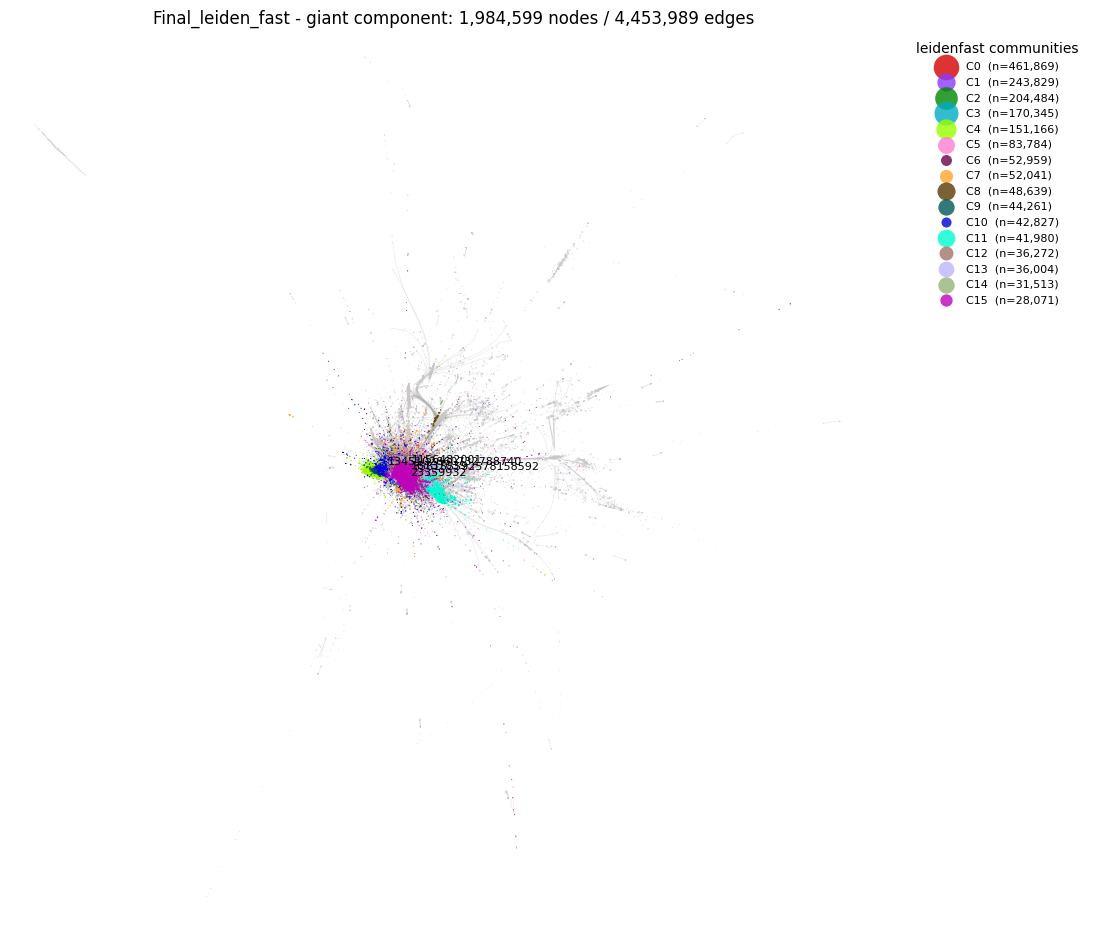

saved /content/drive/My Drive/Colab Projects/AI Public Trust/Data Sets/Networks/viz_outputs_Final_leiden_fast/03_publication_composite.png (+ .pdf)


In [18]:
# --- edge raster only (transparent nodes layer comes from matplotlib) ------ #
cvs = make_canvas()
edge_raster = tf.set_background(
    tf.shade(cvs.line(bundled, "x", "y", agg=ds.count()),
             cmap="#555555", how="eq_hist", alpha=170),
    "white",
).to_pil()

fig, ax = plt.subplots(figsize=(11, 11 * (Y_RANGE[1]-Y_RANGE[0]) / (X_RANGE[1]-X_RANGE[0])))
ax.imshow(edge_raster, extent=(*X_RANGE, *Y_RANGE), origin="upper", zorder=0)

# Nodes: draw 'other' first (grey, underneath), then big communities largest-first.
mpl_size = 0.4 * np.sqrt(nodes["degree"])              # sqrt keeps hubs sane
other = nodes["community"] == "other"
ax.scatter(nodes.loc[other, "x"], nodes.loc[other, "y"],
           s=mpl_size[other], c="#c8c8c8", alpha=0.5, linewidths=0, zorder=1)
for c in tqdm(DISPLAY_ORDER, desc="drawing communities"):
    if c == "other":
        continue
    sel = nodes["community"] == c
    ax.scatter(nodes.loc[sel, "x"], nodes.loc[sel, "y"], s=mpl_size[sel],
               c=COLOR_KEY[c], alpha=0.8, linewidths=0, zorder=2,
               label=f"{c}  (n={int(sel.sum()):,})")

# Annotate the highest-degree account of each of the 5 biggest communities.
for c in [c for c in DISPLAY_ORDER if c != "other"][:5]:
    hub = nodes[nodes["community"] == c].nlargest(1, "degree").iloc[0]
    ax.annotate(hub["label"], (hub["x"], hub["y"]), fontsize=8,
                xytext=(4, 4), textcoords="offset points", zorder=3)

ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False,
          title=f"{COMMUNITY_SOURCE} communities", markerscale=2.5, fontsize=8)
ax.set_axis_off()
ax.set_title(f"{NETWORK} - giant component: {G_giant.vcount():,} nodes / "
             f"{G_giant.ecount():,} edges", fontsize=12)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_publication_composite.png", dpi=200, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "03_publication_composite.pdf", bbox_inches="tight")
plt.show()
print(f"saved {OUTPUT_DIR / '03_publication_composite.png'} (+ .pdf)")

### 5.4 View 4 — interactive exploration with ipysigma

For actually *investigating* the network — hover names, click neighborhoods,
search accounts — nothing beats a WebGL renderer in the notebook.
[ipysigma](https://github.com/medialab/ipysigma) wraps sigma.js, takes
networkx or igraph graphs directly, and can write a **self-contained HTML
file** you can share with collaborators who don't run Python.

WebGL is happiest below ~10⁵ elements, so if the giant component is bigger
than `MAX_NODES_INTERACTIVE` we hand it the **top-degree induced subgraph**
(§2.3) with our precomputed positions — the browser does no layout work
(`start_layout=False` keeps it that way).

In [19]:
from ipysigma import Sigma

# ---- 1. reduce to an interactive-sized subgraph (if needed) --------------- #
G_view = top_degree_subgraph(G_giant, MAX_NODES_INTERACTIVE)
if G_view.ecount() > MAX_EDGES_INTERACTIVE:            # dense cores: thin edges too
    eids = np.random.default_rng(RANDOM_SEED).choice(
        G_view.ecount(), size=MAX_EDGES_INTERACTIVE, replace=False)
    G_view = G_view.subgraph_edges(eids.tolist(), delete_vertices=False)
print(f"interactive view: {G_view.vcount():,} nodes / {G_view.ecount():,} edges")

# ---- 2. convert to networkx and attach visual attributes ------------------ #
# igraph.to_networkx() relabels vertices 0..n-1 and keeps '_igraph_index',
# which we use to look positions/attributes up in the full `nodes` table.
Gx = G_view.to_networkx()
idx = np.asarray([Gx.nodes[n]["_igraph_index"] for n in Gx.nodes()])

sigma_layout = {n: {"x": float(nodes["x"].iat[i]),     # sigma's y axis points
                    "y": float(-nodes["y"].iat[i])}    # down; flip so the view
                for n, i in zip(Gx.nodes(), idx)}      # matches the figures
node_color  = {n: str(nodes["community"].iat[i]) for n, i in zip(Gx.nodes(), idx)}
node_size   = {n: int(nodes["degree"].iat[i])    for n, i in zip(Gx.nodes(), idx)}
node_label  = {n: str(nodes["label"].iat[i])     for n, i in zip(Gx.nodes(), idx)}
nx.set_node_attributes(Gx, node_label, "label")        # hover / search text

sigma_kwargs = dict(
    layout=sigma_layout,          # our precomputed positions ...
    start_layout=False,           # ... and don't run FA2 in the browser
    node_color=node_color,        # categorical -> ipysigma builds a palette
    node_color_palette=COLOR_KEY, # ... but we force the same colors as above
    node_size=node_size,
    node_size_range=(1, 12),
    node_size_scale=("log", 2),   # log-size: hubs visible, tail not invisible
    default_edge_color="#d0d0d0",
    node_border_color_from="node",
    label_density=2,
)
if weights:                       # only meaningful when the GML had weights
    sigma_kwargs.update(edge_size="weight", edge_size_range=(0.3, 3))

# ---- 3. standalone HTML (always) + inline widget (when supported) --------- #
html_path = OUTPUT_DIR / "04_interactive_network.html"
Sigma.write_html(Gx, str(html_path), fullscreen=True, **sigma_kwargs)
print(f"saved {html_path}  <- download & open in any browser")

Sigma(Gx, height=650, **sigma_kwargs)                  # inline widget (last line)

interactive view: 29,358 nodes / 200,000 edges
saved /content/drive/My Drive/Colab Projects/AI Public Trust/Data Sets/Networks/viz_outputs_Final_leiden_fast/04_interactive_network.html  <- download & open in any browser


Sigma(nx.Graph with 29,358 nodes and 200,000 edges)

## 6. Coordinate-free views

Past a few million edges *any* node-link picture saturates. Two classic plots
carry structural information at literally any scale, because they never draw
the graph itself.

### 6.1 Degree distribution (CCDF)

The complementary cumulative distribution `P(K ≥ k)` on log-log axes is the
honest way to show a heavy-tailed degree distribution (binning artifacts of
raw histograms disappear). For rigorous tail *fitting*, use the `powerlaw`
package rather than eyeballing a slope.

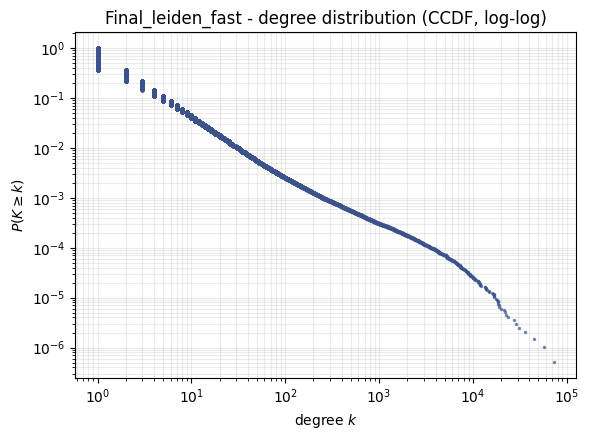

In [42]:
deg_sorted = np.sort(degree)
# CCDF: for each observed degree value, the fraction of nodes with degree >= it
ccdf = 1.0 - np.arange(len(deg_sorted)) / len(deg_sorted)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(deg_sorted, ccdf, marker=".", markersize=3, linestyle="none",
          color="#3b528b", alpha=0.6)
ax.set_xlabel("degree $k$")
ax.set_ylabel(r"$P(K \geq k)$")
ax.set_title(f"{NETWORK} - degree distribution (CCDF, log-log)")
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "05_degree_ccdf.png", dpi=200)
plt.show()

### 6.2 Community-blocked adjacency matrix

Order the nodes by community (largest first, by degree inside each), then
2-D-histogram the edge endpoints over that ordering. Dense diagonal blocks =
cohesive communities; off-diagonal smears = the bridges between them. Because
it's a fixed-size histogram, this works unchanged on a 10-million-edge
graph.

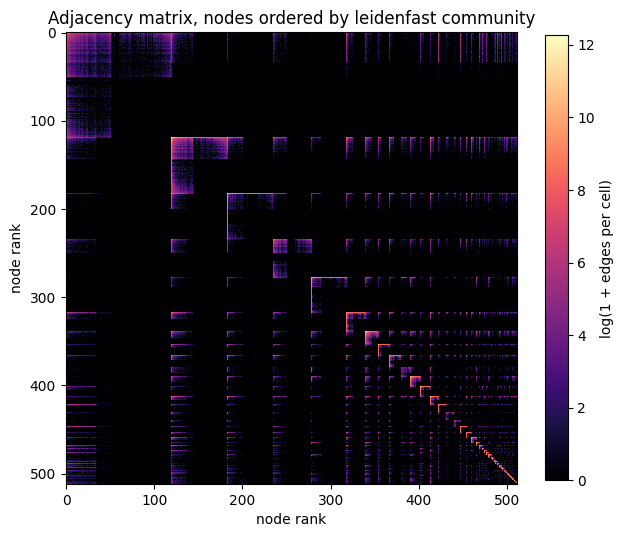

In [43]:
# Permutation: sort nodes by (community size rank, then -degree).
perm = np.lexsort((-nodes["degree"].to_numpy(), nodes["community_rank"].to_numpy()))
pos_of = np.empty(len(perm), dtype=np.int64)
pos_of[perm] = np.arange(len(perm))                    # node id -> matrix row

BINS = 512                                             # fixed cost at any scale
r, c = pos_of[edges["source"].to_numpy()], pos_of[edges["target"].to_numpy()]
H, _, _ = np.histogram2d(np.r_[r, c], np.r_[c, r],     # symmetrize
                         bins=BINS, range=[[0, len(perm)], [0, len(perm)]])

fig, ax = plt.subplots(figsize=(6.5, 6))
im = ax.imshow(np.log1p(H), cmap="magma", origin="upper", interpolation="nearest")
ax.set_title(f"Adjacency matrix, nodes ordered by {COMMUNITY_SOURCE} community")
ax.set_xlabel("node rank"); ax.set_ylabel("node rank")
fig.colorbar(im, ax=ax, label="log(1 + edges per cell)", shrink=0.8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "06_adjacency_blocks.png", dpi=200)
plt.show()

## 7. Save the artifacts

Positions and attributes are the expensive things — persist them so future
sessions (or Gephi) start from here instead of recomputing. The GraphML export
carries `x`/`y`, so opening it in [Gephi](https://gephi.org) /
[Gephi Lite](https://gephi.org/gephi-lite/) shows *this* layout immediately.

In [20]:
# 1) Node table (positions + attributes) - parquet is compact & typed.
nodes.to_parquet(OUTPUT_DIR / "node_positions.parquet")

# 2) GraphML with embedded coordinates & community, for Gephi and friends.
G_export = G_giant.copy()
G_export.vs["x"] = nodes["x"].tolist()
G_export.vs["y"] = nodes["y"].tolist()
G_export.vs["community"] = [str(c) for c in nodes["community"]]
G_export.vs["degree"] = nodes["degree"].tolist()
G_export.write_graphml(str(OUTPUT_DIR / "network_with_layout.graphml"))

print("Artifacts in", OUTPUT_DIR.resolve())
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {p.name:<40} {p.stat().st_size/1e6:6.1f} MB")

Artifacts in /content/drive/My Drive/Colab Projects/AI Public Trust/Data Sets/Networks/viz_outputs_Final_leiden_fast
  00_reframe_preview.png                      1.3 MB
  01_full_network_straight.png                1.5 MB
  02_full_network_bundled.png                 0.8 MB
  03_publication_composite.pdf              319.6 MB
  03_publication_composite.png                1.6 MB
  04_interactive_network.html                56.6 MB
  05_degree_ccdf.png                          0.1 MB
  06_adjacency_blocks.png                     0.2 MB
  network_with_layout.graphml              1204.6 MB
  node_positions.parquet                     63.2 MB


## 8. Run summary

Every stage recorded its wall time, memory and outcome. If a run ever *feels*
slow, this is where you find out which stage to shrink.

In [21]:
summary = pd.DataFrame(STAGE_LOG)
total = summary["seconds"].sum()
print(f"total tracked time: {total:.0f}s ({total/60:.1f} min)")
summary

total tracked time: 454s (7.6 min)


,stage,seconds,status,RSS_GB
0,load GML,38.1,ok,4.58
1,layout (fr),358.5,ok,4.72
2,build edge segments,20.9,ok,4.73
3,render straight-edge view,9.8,ok,4.74
4,hammer edge bundling,23.9,ok,4.74
5,render bundled view,2.4,ok,4.74


## Where to go from here

*Bigger graphs:* switch to the GPU section (§4.4) for layout, and raise
`CANVAS_PX` — Datashader's cost grows with pixels and data size, not with
visual complexity. *Different aesthetics:* `graph-tool`'s `sfdp_layout`
(conda environments) and Gephi's own ForceAtlas2 (via the GraphML export
above) remain the reference looks. *Hosted GPU interactivity:*
[Graphistry](https://www.graphistry.com/) if you can use an external service.
*Deeper analytics on the same objects:* everything here is a plain
`igraph.Graph` plus two pandas tables — centralities, k-cores, temporal
slices and filtering all compose naturally with this pipeline.